# 01. EDA: Telco Customer Churn

Ngày 1-2: Xác định bài toán kinh doanh, tải dữ liệu, khám phá dữ liệu (EDA).

## 0. Bài toán kinh doanh

- **Mục tiêu:** dự đoán xác suất một khách hàng sẽ churn (rời bỏ dịch vụ) trong kỳ tới.
- **Vì sao quan trọng:** chi phí giữ chân khách hàng hiện tại < chi phí thu hút khách hàng mới. Xác định sớm nhóm rủi ro cao giúp bộ phận CSKH can thiệp bằng ưu đãi/giữ chân đúng đối tượng, tránh tốn ưu đãi cho khách không có nguy cơ rời bỏ.
- **Câu hỏi phân tích:**
  1. Tỷ lệ churn tổng thể là bao nhiêu?
  2. Nhóm khách hàng nào (theo hợp đồng, dịch vụ, thời gian gắn bó...) có tỷ lệ churn cao bất thường?
  3. Yếu tố nào ảnh hưởng mạnh nhất đến quyết định rời bỏ?
  4. Với một ngưỡng xác suất cho trước, giữ chân bao nhiêu khách hàng thì lợi ích vượt chi phí?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

## 1. Tải dữ liệu

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.1 Mô tả các cột dữ liệu (Data Dictionary)

| Cột | Ý nghĩa | Kiểu dữ liệu |
|---|---|---|
| `customerID` | Mã định danh khách hàng (duy nhất) | ID |
| `gender` | Giới tính (Male / Female) | Categorical |
| `SeniorCitizen` | Khách hàng cao tuổi (1) hay không (0) | Binary (int) |
| `Partner` | Có vợ/chồng/bạn đời hay không | Categorical (Yes/No) |
| `Dependents` | Có người phụ thuộc (con cái...) hay không | Categorical (Yes/No) |
| `tenure` | Số tháng đã gắn bó với công ty | Numeric |
| `PhoneService` | Có đăng ký dịch vụ điện thoại hay không | Categorical (Yes/No) |
| `MultipleLines` | Có nhiều đường dây điện thoại hay không | Categorical (Yes/No/No phone service) |
| `InternetService` | Loại dịch vụ internet (DSL / Fiber optic / No) | Categorical |
| `OnlineSecurity` | Có đăng ký bảo mật trực tuyến hay không | Categorical (Yes/No/No internet service) |
| `OnlineBackup` | Có đăng ký sao lưu trực tuyến hay không | Categorical (Yes/No/No internet service) |
| `DeviceProtection` | Có đăng ký bảo vệ thiết bị hay không | Categorical (Yes/No/No internet service) |
| `TechSupport` | Có đăng ký hỗ trợ kỹ thuật hay không | Categorical (Yes/No/No internet service) |
| `StreamingTV` | Có đăng ký xem TV trực tuyến hay không | Categorical (Yes/No/No internet service) |
| `StreamingMovies` | Có đăng ký xem phim trực tuyến hay không | Categorical (Yes/No/No internet service) |
| `Contract` | Loại hợp đồng (Month-to-month / One year / Two year) | Categorical |
| `PaperlessBilling` | Có dùng hoá đơn điện tử hay không | Categorical (Yes/No) |
| `PaymentMethod` | Phương thức thanh toán (4 loại) | Categorical |
| `MonthlyCharges` | Phí hàng tháng hiện tại (USD) | Numeric |
| `TotalCharges` | Tổng phí đã thanh toán từ khi bắt đầu hợp đồng (USD) | Numeric |
| `Churn` | **Biến mục tiêu**: khách hàng đã rời bỏ (Yes) hay chưa (No) | Categorical (binary) |

**Ghi chú:**
- 7 cột dịch vụ add-on (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,
  `StreamingTV`, `StreamingMovies`, `MultipleLines`) có thêm giá trị `No internet service` /
  `No phone service`. Về bản chất chỉ là dạng "No" phụ thuộc vào cột gốc
  (`InternetService` / `PhoneService`), không phải hạng mục độc lập, nên cần lưu ý khi
  one-hot encode ở bước feature engineering để tránh dư thừa.
- `SeniorCitizen` là kiểu int (0/1), trong khi các biến nhị phân khác là string Yes/No,
  không đồng nhất định dạng nên cần chuẩn hoá khi encode.
- `TotalCharges` đọc lên là kiểu object do 11 dòng có khoảng trắng thay vì số (khách hàng
  mới, `tenure = 0`, chưa phát sinh phí), đã convert bằng `pd.to_numeric(..., errors='coerce')`
  ở mục 2.
- `customerID` không mang giá trị dự đoán, sẽ loại khỏi tập feature khi modeling.


## 2. Kiểm tra tổng quan: dtypes, missing values, giá trị lạ

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# TotalCharges thường bị đọc là object do có khoảng trắng ở một số dòng (khách hàng mới, tenure=0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isna().sum().sort_values(ascending=False).head(10)

TotalCharges      11
gender             0
SeniorCitizen      0
Partner            0
customerID         0
Dependents         0
tenure             0
MultipleLines      0
PhoneService       0
OnlineSecurity     0
dtype: int64

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Kiểm tra trùng lặp customerID và cardinality của các biến categorical
print('Số customerID trùng lặp:', df['customerID'].duplicated().sum())
print()
cat_cols_check = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])
print('Số giá trị duy nhất mỗi cột categorical (cardinality):')
print(df[cat_cols_check].nunique().sort_values())

Số customerID trùng lặp: 0

Số giá trị duy nhất mỗi cột categorical (cardinality):
gender              2
Partner             2
Dependents          2
PhoneService        2
PaperlessBilling    2
MultipleLines       3
OnlineSecurity      3
InternetService     3
OnlineBackup        3
DeviceProtection    3
StreamingTV         3
TechSupport         3
StreamingMovies     3
Contract            3
PaymentMethod       4
dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_14592\723069889.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_check = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])


## 3. Tỷ lệ churn tổng thể

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


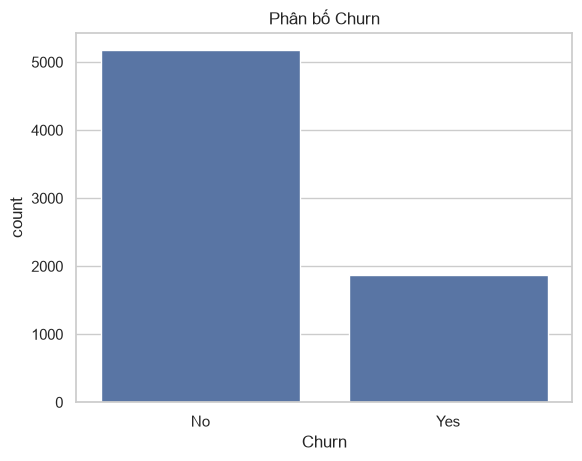

In [7]:
churn_rate = df['Churn'].value_counts(normalize=True)
print(churn_rate)
sns.countplot(data=df, x='Churn')
plt.title('Phân bố Churn')
plt.savefig('../reports/figures/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Churn theo các yếu tố ảnh hưởng mạnh nhất

(dựa trên Cramér's V ở mục 5.1, Nhóm Cramer với V > 0.28: `Contract`, `InternetService`, `PaymentMethod`, `OnlineSecurity`, `TechSupport`, `PaperlessBilling`. Các biến còn lại (OnlineBackup, DeviceProtection, StreamingTV/Movies, demographics...) xem ở bảng mục 5.1.

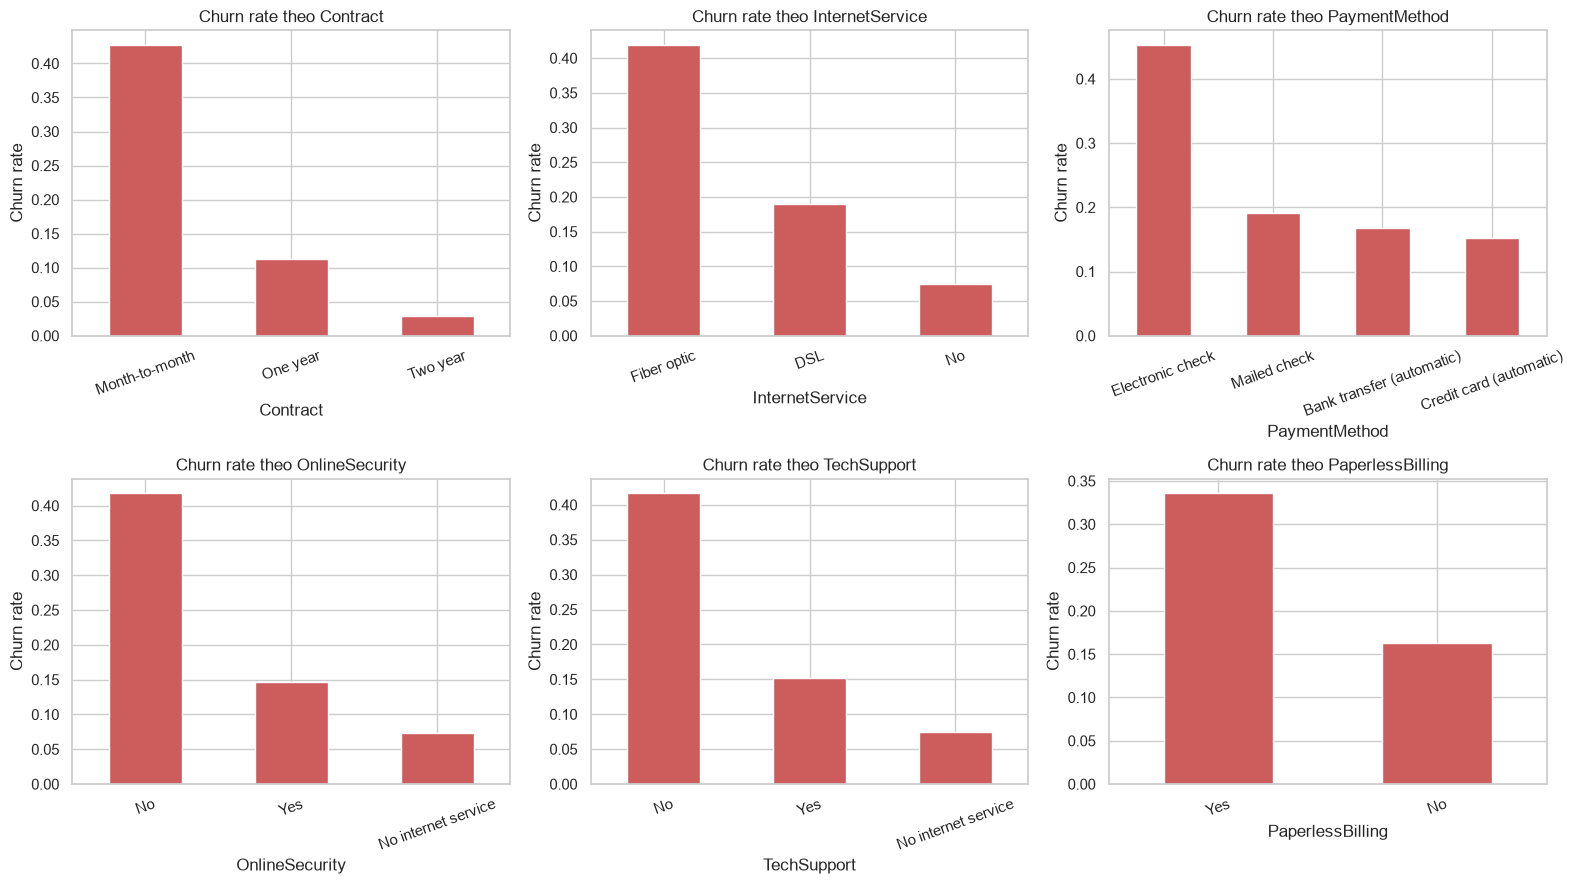

In [8]:
top_driver_cols = ['Contract', 'InternetService', 'PaymentMethod',
                    'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), top_driver_cols):
    churn_by_col = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    churn_by_col.plot(kind='bar', ax=ax, color='indianred')
    ax.set_title(f'Churn rate theo {col}')
    ax.set_ylabel('Churn rate')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../reports/figures/churn_by_top_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Tóm tắt nhanh các biến số theo nhóm churn 
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(1)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.6,61.3,2555.3
Yes,18.0,74.4,1531.8


Nhóm Khách ở lại Trung bình đã dùng được 3 năm dịch vụ (37.6 tháng), thanh toán hằng tháng 60$ và tổng tích lũy avg 2500$

Nhóm rời đi trung bình chưa dùng được 1 năm rưỡi dịch dụ, hằng tháng lại thanh toán nhiều hơn nhóm khách cũ 10$

Tổng thu từ nhóm khách cũ gắp hơn 5/3 lần nhóm Khách Churn cho dù thời gian dịch vụ dài gấp đôi.

Cho thấy rằng nhóm Churn họ có xu hướng thuê dịch vụ ngắn hạn với mức phí tháng cao hơn và dễ rời đi khi không bị ràng buộc bởi gia hạn. 

## 5. Phân tích: kiểm định thống kê, tương tác biến, phân khúc chi tiết

Các biểu đồ ở mục 4 cho thấy churn rate khác nhau theo từng biến, nhưng chưa cho biết mức
độ ảnh hưởng nào **có ý nghĩa thống kê**, và chưa cho thấy
**tương tác giữa các biến** (một khách Month-to-month + Fiber optic có thể rủi ro cao hơn
nhiều so với khi chỉ xét từng biến riêng lẻ). 

### 5.1 Kiểm định ý nghĩa thống kê (Chi-square + Cramér's V)

Dùng chi-square test of independence để kiểm tra mỗi biến categorical có thực sự liên quan tới `Churn` hay không (p-value), và **Cramér's V** để đo độ mạnh của mối liên hệ đó [0;1]. Nhờ vậy có thể xếp hạng biến quan trọng một cách định lượng thay vì chỉ nhìn biểu đồ bằng mắt.

In [10]:
from scipy.stats import chi2_contingency

def cramers_v(col):
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    cv = np.sqrt(phi2 / min(r - 1, k - 1))
    return chi2, p, cv

cat_cols_all = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling',
                'TechSupport', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'StreamingTV', 'StreamingMovies', 'MultipleLines', 'PhoneService',
                'SeniorCitizen', 'Partner', 'Dependents', 'gender']

results = []
for col in cat_cols_all:
    chi2, p, cv = cramers_v(col)
    results.append({'feature': col, 'chi2': chi2, 'p_value': p, 'cramers_v': cv})

stat_df = pd.DataFrame(results).sort_values('cramers_v', ascending=False).reset_index(drop=True)
stat_df

,feature,chi2,p_value,cramers_v
0,Contract,1184.596572,5.863038e-258,0.410116
1,OnlineSecurity,849.998968,2.661150e-185,0.347400
2,TechSupport,828.197068,1.443084e-180,0.342916
3,InternetService,732.309590,9.571788e-160,0.322455
4,PaymentMethod,648.142327,3.682355e-140,0.303359
5,OnlineBackup,601.812790,2.079759e-131,0.292316
6,DeviceProtection,558.419369,5.505219e-122,0.281580
7,StreamingMovies,375.661479,2.667757e-82,0.230951
8,StreamingTV,374.203943,5.528994e-82,0.230502
9,PaperlessBilling,258.277649,4.073355e-58,0.191498


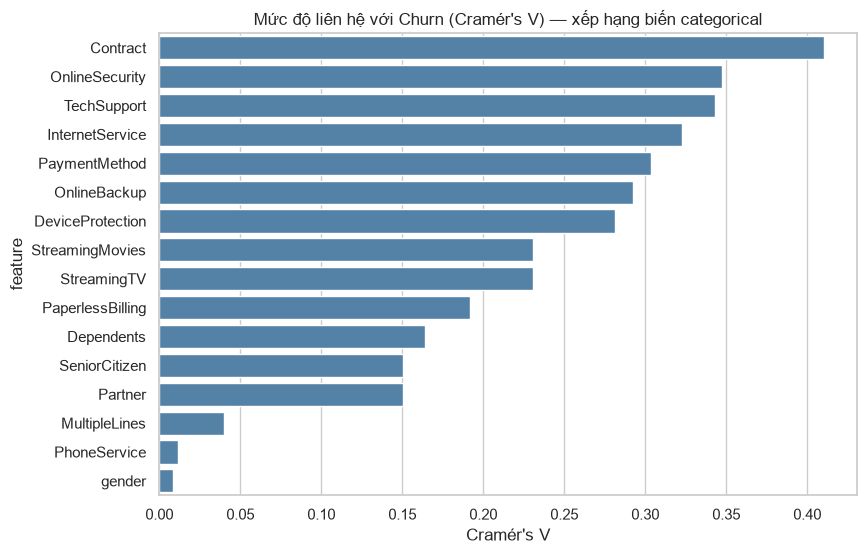

In [11]:
plt.figure(figsize=(9, 6))
sns.barplot(data=stat_df, x='cramers_v', y='feature', color='steelblue')
plt.title("Mức độ liên hệ với Churn (Cramér's V) — xếp hạng biến categorical")
plt.xlabel("Cramér's V")
plt.savefig('../reports/figures/cramers_v_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Tương quan giữa các biến số

Chỉ có 3 biến số (`tenure`, `MonthlyCharges`, `TotalCharges`)

In [12]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)
numeric_df.corr().round(2)

,tenure,MonthlyCharges,TotalCharges,ChurnFlag
tenure,1.00,0.25,0.83,-0.35
MonthlyCharges,0.25,1.00,0.65,0.19
TotalCharges,0.83,0.65,1.00,-0.20
ChurnFlag,-0.35,0.19,-0.20,1.00


### 5.3 Phân tích tương tác: kết hợp 2 biến cùng lúc

Xét churn rate theo **cặp biến** để tìm ra các "combo" khách hàng rủi ro cao nhất một cách
cụ thể, thay vì chỉ nhìn từng biến độc lập.

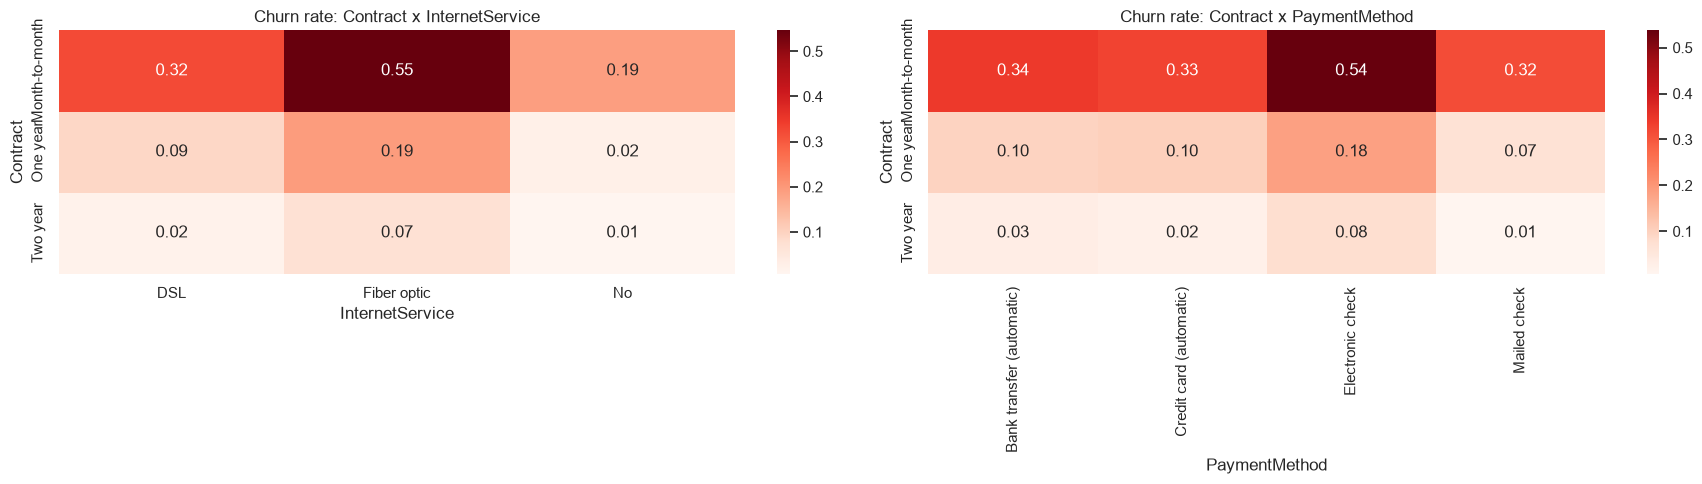

In [13]:
pivot_contract_internet = df.pivot_table(index='Contract', columns='InternetService',
                                          values='Churn', aggfunc=lambda x: (x == 'Yes').mean())
pivot_contract_payment = df.pivot_table(index='Contract', columns='PaymentMethod',
                                         values='Churn', aggfunc=lambda x: (x == 'Yes').mean())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.heatmap(pivot_contract_internet, annot=True, fmt='.2f', cmap='Reds', ax=axes[0])
axes[0].set_title('Churn rate: Contract x InternetService')
sns.heatmap(pivot_contract_payment, annot=True, fmt='.2f', cmap='Reds', ax=axes[1])
axes[1].set_title('Churn rate: Contract x PaymentMethod')
plt.tight_layout()
plt.savefig('../reports/figures/churn_interaction_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

Key: (Fiber optic + M-to-M) và (Electronic + M-to-M) 

### 5.4 Số lượng dịch vụ add-on đăng ký vs Churn

Tạo biến phái sinh `NumAddonServices` = tổng số dịch vụ add-on khách hàng đang đăng ký
(`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`,
`StreamingMovies`).

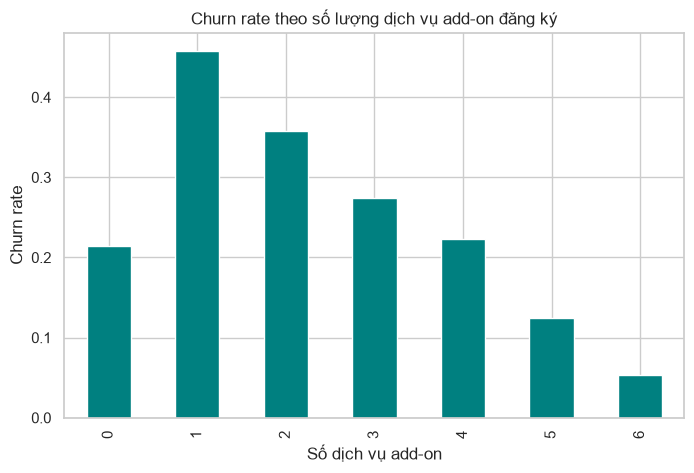

NumAddonServices
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn, dtype: float64

In [14]:
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies']
df['NumAddonServices'] = (df[addon_cols] == 'Yes').sum(axis=1)

churn_by_numaddon = df.groupby('NumAddonServices')['Churn'].apply(lambda x: (x == 'Yes').mean())
plt.figure(figsize=(8, 5))
churn_by_numaddon.plot(kind='bar', color='teal')
plt.title('Churn rate theo số lượng dịch vụ add-on đăng ký')
plt.xlabel('Số dịch vụ add-on')
plt.ylabel('Churn rate')
plt.savefig('../reports/figures/churn_by_numaddon.png', dpi=150, bbox_inches='tight')
plt.show()
churn_by_numaddon

### 5.5 Tenure theo nhóm (bucket): mốc thời gian rủi ro

để hình dung thời gian can thiệp giữ chân. Chia `tenure` thành các nhóm để xác định rõ mốc thời gian nào churn rate giảm mạnh nhất.

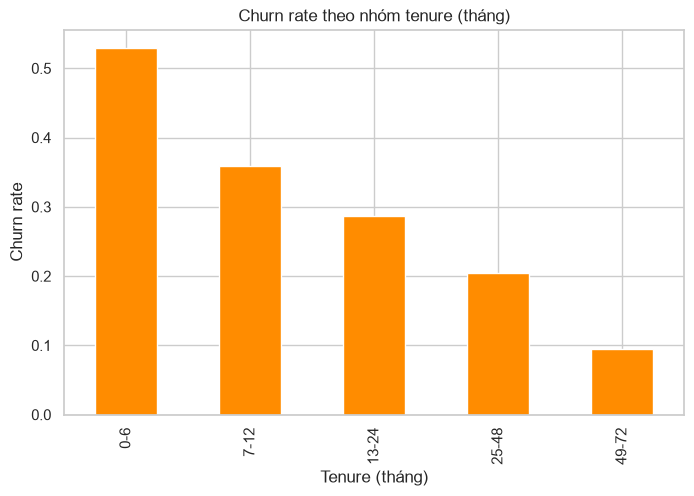

tenure_bucket
0-6      0.529372
7-12     0.358865
13-24    0.287109
25-48    0.203890
49-72    0.095132
Name: Churn, dtype: float64

In [15]:
bins = [0, 6, 12, 24, 48, 72]
labels = ['0-6', '7-12', '13-24', '25-48', '49-72']
df['tenure_bucket'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

churn_by_tenure_bucket = df.groupby('tenure_bucket', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean())
plt.figure(figsize=(8, 5))
churn_by_tenure_bucket.plot(kind='bar', color='darkorange')
plt.title('Churn rate theo nhóm tenure (tháng)')
plt.xlabel('Tenure (tháng)')
plt.ylabel('Churn rate')
plt.savefig('../reports/figures/churn_by_tenure_bucket.png', dpi=150, bbox_inches='tight')
plt.show()
churn_by_tenure_bucket

### 5.6 Giá trị khách hàng đã tích luỹ (TotalCharges) và churn

Cần số ước tính doanh thu đã "mất" tính đến hiện tại từ nhóm khách churn, để có cảm nhận quy mô tác động kinh doanh .

In [16]:
lost_value = df.loc[df['Churn'] == 'Yes', 'TotalCharges'].sum()
total_value = df['TotalCharges'].sum()
print(f'Tổng TotalCharges đã tích luỹ của nhóm khách đã churn: {lost_value:,.0f} USD')
print(f'Tỷ trọng trên tổng TotalCharges toàn bộ khách hàng: {lost_value/total_value:.1%}')

Tổng TotalCharges đã tích luỹ của nhóm khách đã churn: 2,862,927 USD
Tỷ trọng trên tổng TotalCharges toàn bộ khách hàng: 17.8%


### 5.7 Segment cụ thể: khách hàng khớp đủ nhiều điều kiện rủi ro cùng lúc, xác thực bằng train/validation/test

**Một khách hàng khớp ĐỦ nhiều điều kiện rủi ro cùng lúc thì churn rate là bao nhiêu?**

**Rủi ro phương pháp luận cần tránh (data dredging):** 2 combo mạnh nhất ở mục 5.3 (Month-
to-month + Fiber optic, Month-to-month + Electronic check) được tìm ra bằng cách nhìn toàn
bộ dữ liệu. Nếu ghép 2 combo đó thành 1 rule mới (AND thêm điều kiện tenure) rồi báo
cáo churn rate của chính rule đó con số sẽ lạc quan hơn thực tế. 

**Cách xử lý (nhất quán với quy trình modeling):** tái tạo lại đúng 3 tập
**train/validation/test (60/20/20, stratified)** đã tạo ở
`02_feature_engineering.ipynb`, dùng lại `src/features.py` để đảm bảo cùng thứ tự xử lý
dữ liệu.
- **Train:** dùng để định nghĩa rule (đúng rule đã thấy ở mục 5.3: Month-to-month + Fiber
  optic + Electronic check + tenure < 6 tháng).
- **Validation:** kiểm tra rule có giữ được churn rate tương tự không, nếu lệch nhiều so
  với train nghĩa là rule bị overfit vào mẫu train, cần bỏ bớt điều kiện.
- **Test:** chỉ đo đúng 1 lần, dùng làm con số chốt cuối cùng để báo cáo (README, business
  summary), không dùng để tinh chỉnh rule.

In [ ]:
import sys
sys.path.append('../src')
from sklearn.model_selection import train_test_split
import features as fe

RANDOM_STATE = 42

# Tái tạo đúng split 60/20/20 dùng ở 02_feature_engineering.ipynb (cùng hàm trong
# features.py + cùng random_state) : đảm bảo customerID ở mỗi tập khớp 100% với

df_fe = fe.engineer_features(fe.consolidate_service_columns(fe.clean_data(fe.load_raw_data(DATA_PATH))))
y_fe = fe.encode_target(df_fe)

df_temp, df_test_seg, y_temp, y_test_seg = train_test_split(
    df_fe, y_fe, test_size=0.2, stratify=y_fe, random_state=RANDOM_STATE
)
df_train_seg, df_val_seg, y_train_seg, y_val_seg = train_test_split(
    df_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)


def match_segment(d, broad=False):
    cond_month = d['Contract'] == 'Month-to-month'
    cond_fiber = d['InternetService'] == 'Fiber optic'
    cond_echeck = d['PaymentMethod'] == 'Electronic check'
    cond_tenure = d['tenure'] < 6
    if broad:
        return d[cond_month & (cond_fiber | cond_echeck)]
    return d[cond_month & cond_fiber & cond_echeck & cond_tenure]


def segment_stats(d_split, broad=False):
    """Churn rate + 95% CI (xấp xỉ chuẩn) của segment trên 1 tập dữ liệu cho trước."""
    overall = (d_split['Churn'] == 'Yes').mean()
    seg = match_segment(d_split, broad=broad)
    n = len(seg)
    rate = (seg['Churn'] == 'Yes').mean()
    se = (rate * (1 - rate) / n) ** 0.5
    return {
        'n_total': len(d_split), 'overall_rate': overall,
        'n_segment': n, 'pct_of_total': n / len(d_split),
        'churn_rate': rate, 'ci_low': max(0, rate - 1.96 * se), 'ci_high': min(1, rate + 1.96 * se),
        'lift': rate / overall,
    }


print('=== Segment HẸP (4 điều kiện) — rule định nghĩa trên TRAIN, xác nhận trên VALIDATION, chốt trên TEST ===')
splits_seg = [
    ('TRAIN (định nghĩa rule)', df_train_seg),
    ('VALIDATION (xác nhận)', df_val_seg),
    ('TEST (chốt, chạm đúng 1 lần)', df_test_seg),
]
for name, d in splits_seg:
    s = segment_stats(d, broad=False)
    print(f"{name:32s}: n={s['n_total']:>4} | segment n={s['n_segment']:>3} ({s['pct_of_total']:.1%}) "
          f"| churn={s['churn_rate']:.1%} 95%CI=[{s['ci_low']:.1%},{s['ci_high']:.1%}] | lift={s['lift']:.2f}x")

print()
print('=== Segment RỘNG (nới lỏng: Fiber optic HOẶC Electronic check) — cùng phương pháp ===')
for name, d in splits_seg:
    s = segment_stats(d, broad=True)
    print(f"{name:32s}: n={s['n_total']:>4} | segment n={s['n_segment']:>3} ({s['pct_of_total']:.1%}) "
          f"| churn={s['churn_rate']:.1%} 95%CI=[{s['ci_low']:.1%},{s['ci_high']:.1%}] | lift={s['lift']:.2f}x")

# Số liệu CHỐT để dùng ở README/business summary: đo trên TEST — chưa từng dùng để định
# nghĩa/tinh chỉnh rule, nên không bị lạc quan hoá do data dredging.
test_narrow = segment_stats(df_test_seg, broad=False)
test_broad = segment_stats(df_test_seg, broad=True)
train_narrow = segment_stats(df_train_seg, broad=False)
val_narrow = segment_stats(df_val_seg, broad=False)

# Segment trên toàn bộ khách hàng (7.043) -> đây là danh sách THẬT dùng để hành động
# (CSKH liên hệ), tách biệt với việc xác thực con số churn rate ở trên.
overall_rate_full = (df_fe['Churn'] == 'Yes').mean()
segment_narrow_full = match_segment(df_fe, broad=False)
segment_broad_full = match_segment(df_fe, broad=True)

print()
print(f"-> Số liệu CHỐT (đo trên test set, đã xác thực, không phải dò mẫu): segment hẹp churn "
      f"{test_narrow['churn_rate']:.1%} (95%CI {test_narrow['ci_low']:.1%}-{test_narrow['ci_high']:.1%}), "
      f"ổn định qua cả 3 tập (train {train_narrow['churn_rate']:.1%}, validation {val_narrow['churn_rate']:.1%}) "
      f"-> không phải data dredging.")
print(f"-> Danh sách hành động thực tế (áp dụng rule trên toàn bộ khách hàng, không phải để đo churn rate): "
      f"{len(segment_narrow_full)} khách hàng ({len(segment_narrow_full)/len(df_fe):.1%} tổng).")

=== Segment HẸP (4 điều kiện) — rule định nghĩa trên TRAIN, xác nhận trên VALIDATION, chốt trên TEST ===
TRAIN (định nghĩa rule)         : n=4225 | segment n=261 (6.2%) | churn=75.5% 95%CI=[70.3%,80.7%] | lift=2.84x
VALIDATION (xác nhận)           : n=1409 | segment n= 64 (4.5%) | churn=75.0% 95%CI=[64.4%,85.6%] | lift=2.83x
TEST (chốt, chạm đúng 1 lần)    : n=1409 | segment n= 85 (6.0%) | churn=78.8% 95%CI=[70.1%,87.5%] | lift=2.97x

=== Segment RỘNG (nới lỏng: Fiber optic HOẶC Electronic check) — cùng phương pháp ===
TRAIN (định nghĩa rule)         : n=4225 | segment n=1596 (37.8%) | churn=51.9% 95%CI=[49.5%,54.4%] | lift=1.96x
VALIDATION (xác nhận)           : n=1409 | segment n=543 (38.5%) | churn=50.6% 95%CI=[46.4%,54.8%] | lift=1.91x
TEST (chốt, chạm đúng 1 lần)    : n=1409 | segment n=532 (37.8%) | churn=49.4% 95%CI=[45.2%,53.7%] | lift=1.86x

-> Số liệu CHỐT (đo trên test set, đã xác thực, không phải dò mẫu): segment hẹp churn 78.8% (95%CI 70.1%-87.5%), ổn định qua cả 3 tập (tr

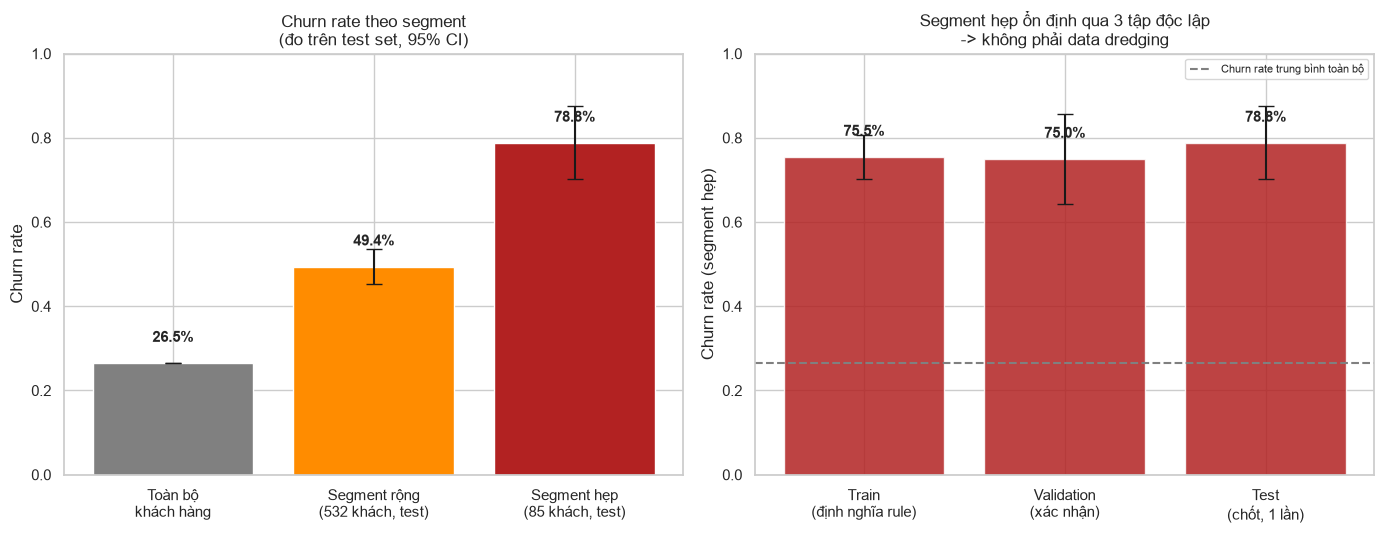

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) "Money chart": overall vs. segment rộng vs. segment hẹp — đo trên TEST set (số liệu
# chốt, chưa từng dùng để định nghĩa rule), kèm 95% CI dưới dạng error bar.
labels_a = ['Toàn bộ\nkhách hàng',
            f"Segment rộng\n({test_broad['n_segment']} khách, test)",
            f"Segment hẹp\n({test_narrow['n_segment']} khách, test)"]
rates_a = [test_narrow['overall_rate'], test_broad['churn_rate'], test_narrow['churn_rate']]
errs_a = [0,
          (test_broad['ci_high'] - test_broad['ci_low']) / 2,
          (test_narrow['ci_high'] - test_narrow['ci_low']) / 2]
bars_a = axes[0].bar(labels_a, rates_a, yerr=errs_a, capsize=6,
                     color=['gray', 'darkorange', 'firebrick'])
for bar, v in zip(bars_a, rates_a):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.05, f'{v:.1%}',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Churn rate')
axes[0].set_title('Churn rate theo segment\n(đo trên test set, 95% CI)')

# (b) Bằng chứng segment hẹp không phải data dredging: churn rate ổn định qua 3 tập độc
# lập (train dùng để định nghĩa rule, validation/test chưa từng thấy rule lúc định nghĩa).
splits_labels = ['Train\n(định nghĩa rule)', 'Validation\n(xác nhận)', 'Test\n(chốt, 1 lần)']
narrow_rates = [train_narrow['churn_rate'], val_narrow['churn_rate'], test_narrow['churn_rate']]
narrow_errs = [(train_narrow['ci_high'] - train_narrow['ci_low']) / 2,
               (val_narrow['ci_high'] - val_narrow['ci_low']) / 2,
               (test_narrow['ci_high'] - test_narrow['ci_low']) / 2]
bars_b = axes[1].bar(splits_labels, narrow_rates, yerr=narrow_errs, capsize=6,
                     color='firebrick', alpha=0.85)
axes[1].axhline(test_narrow['overall_rate'], color='gray', linestyle='--',
                 label='Churn rate trung bình toàn bộ')
for bar, v in zip(bars_b, narrow_rates):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.05, f'{v:.1%}',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Churn rate (segment hẹp)')
axes[1].set_title('Segment hẹp ổn định qua 3 tập độc lập\n-> không phải data dredging')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/churn_by_risk_segment.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ghi chú insight ban đầu

**Chất lượng dữ liệu:**
- 7.043 khách hàng, không có `customerID` trùng lặp, cardinality các biến categorical hợp
  lý (tối đa 4 hạng mục ở `PaymentMethod`). Không có red flag cần xử lý đặc biệt ngoài
  `TotalCharges` (11 dòng missing, tenure=0) đã convert ở mục 2.
- Tỷ lệ churn tổng thể **26,5%**, mất cân bằng lớp, cần `class_weight` hoặc
  resampling ở bước feature engineering.


**Xếp hạng biến theo mức độ ảnh hưởng (Cramér's V, mục 5.1):**
1. `Contract`: **0,41** (mạnh nhất, p ≈ 0)
2. `OnlineSecurity`: 0,35
3. `TechSupport` (0,34), `InternetService` (0,32), `PaymentMethod` (0,30)
4. `OnlineBackup` (0,29), `DeviceProtection` (0,28), `StreamingMovies`/`StreamingTV` (~0,23)
5. `PaperlessBilling` (0,19), `Dependents`/`SeniorCitizen`/`Partner` (~0,15-0,16)
6. `MultipleLines`: rất yếu (0,04) dù vẫn có ý nghĩa thống kê (p=0,003)
7. **`PhoneService` (p=0,34) và `gender` (p=0,49) không có ý nghĩa thống kê** với churn.
   → Hai biến này gần như không có giá trị dự đoán, có thể loại hoặc hạ ưu tiên khi
   modeling.



**Tương quan biến số với churn (mục 5.2):** 
- `tenure` tương quan âm mạnh nhất (-0,35, gắn bó lâu >> ít churn)
- `TotalCharges` cũng âm (-0,20, nhưng phần lớn là do tương quan với tenure chứ không phải hiệu ứng độc lập)
- `MonthlyCharges` tương quan dương nhẹ (+0,19, phí cao → dễ churn hơn).


**Combo rủi ro cao nhất, phân tích tương tác (mục 5.3):** phát hiện đáng chú ý nhất vì churn rate của combo cao **hơn hẳn** so với xét
từng biến riêng lẻ:
- **Month-to-month + Fiber optic: 54,6% churn** (so với Month-to-month nói chung 42,7%).

- **Month-to-month + Electronic check: 53,7% churn**.

- Ngược lại, Two year + bất kỳ payment method nào đều churn rất thấp (0,8%-3,4%).

- → Nhóm ưu tiên can thiệp: khách hàng **Month-to-month** dùng **Fiber optic** hoặc trả
  bằng **Electronic check**, rủi ro vượt 50% (> mức trung bình 26,5%).


**Số dịch vụ add-on (mục 5.4), phản trực giác:** churn rate KHÔNG giảm dần đều
theo số add-on. 

- Nhóm 0 add-on chỉ churn 21,4%, nhưng nhóm **1 add-on lại churn cao nhất
(45,8%)**, sau đó giảm dần đều (2: 35,8% → 6: 5,3%). 

- Lý do là nhóm "0 add-on" gồm cả khách
không có internet (nên không thể đăng ký add-on, và nhóm này vốn đã ít churn ~7,4%), làm
lệch số trung bình. 

- Từ 1 add-on trở lên, xu hướng rõ ràng: **càng đăng ký nhiều dịch vụ
add-on, càng ít churn**, gợi ý dùng add-on như một đòn bẩy giữ chân (upsell OnlineSecurity/
TechSupport cho khách rủi ro cao).


**Tenure bucket (mục 5.5), mốc thời gian rủi ro rõ ràng:** churn giảm đơn điệu và mạnh
theo thời gian gắn bó. Vậy thời gian quan trọng nhất để can thiệp là lúc Khách mới.
- **0-6 tháng: 52,9%** : **6 tháng đầu tiên là giai đoạn rủi ro cao nhất**,
- 7-12 tháng: 35,9% 
- 13-24 tháng: 28,7% 
- 25-48 tháng: 20,4% 
- 49-72 tháng: 9,5%. 


**Tác động kinh doanh (mục 5.6):** nhóm khách hàng đã churn chiếm **17,8%** tổng giá trị
`TotalCharges` (16,06 triệu USD), cho thấy quy mô doanh thu đã mất là đáng kể.


**Segment cụ thể (mục 5.7), đã xác thực out-of-sample, không phải data dredging:**
> Rule (Month-to-month + Fiber optic + Electronic check + tenure < 6 tháng) được định
> nghĩa trên **train**,xác nhận trên **validation**, và đo số liệu chốt đúng 1 lần trên **test**. 

> Churn rate ổn định qua cả 3 tập: train 75,5%, validation 75,0%, **test 78,8% (95% CI 70,1%-87,5%, n=85)**, không
> lệch nhiều so với nhau, nghĩa là tín hiệu thật. Áp dụng rule này trên **toàn bộ 7.043 khách hàng**: **410 khách hàng (5,8%
> tổng), churn rate 76,1%**, gấp **~2,9 lần** mức trung bình 26,5%, và là danh sách
> hành động thực tế cho đội CSKH. 

> Nới lỏng điều kiện (chỉ cần Month-to-month + Fiber optic HOẶC Electronic check) cũng ổn định tương tự qua 3 tập (test: 49,4%, 95% CI 45,2%-53,7%): **2.671 khách (37,9% tổng), churn 51,2%** trên toàn bộ khách hàng. 

>Dùng segment rộng cho chiến dịch giữ chân quy mô lớn, dùng 410 khách segment hẹp làm danh sách ưu tiên can thiệp 1-1 cao nhất.

**Giả thuyết cho feature engineering / modeling:**
- Ưu tiên các biến Cramér's V cao (Contract, OnlineSecurity, TechSupport,
  InternetService, PaymentMethod, tenure, MonthlyCharges); cân nhắc gộp
  `gender`/`PhoneService` vì không có ý nghĩa thống kê.
- Tạo thêm feature phái sinh: `tenure_bucket`, `NumAddonServices` (đã thử nghiệm ở mục
  5.4-5.5, cho thấy tín hiệu rõ ràng), đưa vào tập feature chính thức ở
  `02_feature_engineering.ipynb`.
- Cân nhắc feature tương tác (`Contract` x `InternetService`, `Contract` x
  `PaymentMethod`) hoặc để mô hình tree-based (RF/XGBoost/LightGBM) tự học tương tác này.
- Xử lý mất cân bằng lớp (26,5% churn) bằng `class_weight='balanced'` hoặc SMOTE.

**Tiếp theo:** sang `02_feature_engineering.ipynb` để encode biến, tạo tenure bucket,
NumAddonServices, xử lý mất cân bằng lớp trước khi modeling.